In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import cv2

# Configuration
scene_id = "scene_00018"
texture_id = "texture_00"
run_id = "run_0"

# Load the assignments.npz file
assignments_path = f"/home/esli/GenMatter/video_gestalt_masks/{scene_id}/{texture_id}/{run_id}/assignments.npz"
data = np.load(assignments_path)

# Print what's in the file
print("Arrays in the .npz file:")
for key in data.files:
    print(f"  {key}: shape={data[key].shape}, dtype={data[key].dtype}")
print()

# Store the data for inspection
assignments_data = {key: data[key] for key in data.files}
data.close()

# Load ground truth video frames
video_path = f"/home/esli/GenMatter/assets/from_thomas/{scene_id}/{texture_id}/output_six_frame.mp4"

print(f"Loading ground truth video from: {video_path}")
cap = cv2.VideoCapture(video_path)

gt_frames = []
frame_count = 0
max_frames = 5

while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    gt_frames.append(frame_rgb)
    frame_count += 1

cap.release()

gt_frames = np.array(gt_frames)
print(f"Loaded {len(gt_frames)} ground truth frames with shape: {gt_frames.shape}")

# assignments_data

Arrays in the .npz file:
  blob_assignments: shape=(5, 96, 96), dtype=int32
  hyperblob_assignments_per_blob: shape=(5, 100), dtype=int32
  pixel_hyperblob_assignments: shape=(5, 96, 96), dtype=int64
  roi_hyperblob_ids: shape=(5,), dtype=int64
  hyperblob_sample_counts: shape=(5, 96, 96, 6), dtype=int64
  target_hw: shape=(), dtype=int64
  num_blobs: shape=(), dtype=int64
  num_hyperblobs: shape=(), dtype=int64

Loading ground truth video from: /home/esli/GenMatter/assets/from_thomas/scene_00018/texture_00/output_six_frame.mp4
Loaded 5 ground truth frames with shape: (5, 1000, 1000, 3)


In [2]:
# Summary of data structure
print("Data structure summary:")
print("=" * 60)
print(f"Number of frames: 5")
print(f"Number of blobs: {assignments_data['num_blobs']}")
print(f"Number of hyperblobs: {assignments_data['num_hyperblobs']}")
print()
print("Binary grouping:")
print("  - Object: Hyperblob 0 (will show as black/0)")
print("  - Background: Hyperblobs 1-4 (will show as white/1)")
print("  - Outliers: -1 (will show as black/0, combined with object)")
print()
print(f"pixel_hyperblob_assignments: {assignments_data['pixel_hyperblob_assignments'].shape}")
print("  -> Maps each pixel to a hyperblob ID")
print()
print(f"hyperblob_sample_counts: {assignments_data['hyperblob_sample_counts'].shape}")
print("  -> Posterior probability distribution over hyperblobs for each pixel")
print("=" * 60)

Data structure summary:
Number of frames: 5
Number of blobs: 100
Number of hyperblobs: 5

Binary grouping:
  - Object: Hyperblob 0 (will show as black/0)
  - Background: Hyperblobs 1-4 (will show as white/1)
  - Outliers: -1 (will show as black/0, combined with object)

pixel_hyperblob_assignments: (5, 96, 96)
  -> Maps each pixel to a hyperblob ID

hyperblob_sample_counts: (5, 96, 96, 6)
  -> Posterior probability distribution over hyperblobs for each pixel


In [3]:
# Get the hyperblob data
pixel_hyperblob_assignments = assignments_data['pixel_hyperblob_assignments']
hyperblob_sample_counts = assignments_data['hyperblob_sample_counts']

print(f"Original pixel hyperblob assignments shape: {pixel_hyperblob_assignments.shape}")
print(f"Unique hyperblob IDs: {np.unique(pixel_hyperblob_assignments)}")
print(f"  -1: Outliers")
print(f"   0: Object")
print(f"   1+: Background")
print(f"Sample counts shape: {hyperblob_sample_counts.shape}")

# Create binary segmentation: 1 = object, 0 = background (including outliers)
# Hyperblob 0 is object, hyperblobs 1+ are background, -1 are outliers (treated as background)
binary_segmentation = (pixel_hyperblob_assignments == 0).astype(int)
print(f"\nBinary segmentation created:")
print(f"  1 (white) = Object (hyperblob 0)")
print(f"  0 (black) = Background (hyperblobs > 0) and outliers (-1)")

# Convert sample counts to posterior probabilities
# Need to figure out the actual ordering of channels in sample_counts
# Let's check by examining pixels we know are object vs background
print("\nDetermining channel ordering:")
print("Sample counts has shape:", hyperblob_sample_counts.shape)

# Find a pixel that's definitely object (hyperblob 0)
object_mask = (pixel_hyperblob_assignments == 0)
if object_mask.any():
    obj_indices = np.argwhere(object_mask)
    obj_idx = obj_indices[0]
    print(f"\nPixel at {obj_idx} is hyperblob 0 (object)")
    print(f"Sample counts: {hyperblob_sample_counts[tuple(obj_idx)]}")

# Find a pixel that's definitely background (hyperblob 1+)
bg_mask = (pixel_hyperblob_assignments > 0)
if bg_mask.any():
    bg_indices = np.argwhere(bg_mask)
    bg_idx = bg_indices[0]
    print(f"\nPixel at {bg_idx} is hyperblob {pixel_hyperblob_assignments[tuple(bg_idx)]} (background)")
    print(f"Sample counts: {hyperblob_sample_counts[tuple(bg_idx)]}")

# Normalize to probabilities
posterior_all = hyperblob_sample_counts.astype(float)
posterior_sum = posterior_all.sum(axis=-1, keepdims=True)
posterior_sum[posterior_sum == 0] = 1  # Avoid division by zero
posterior_all = posterior_all / posterior_sum

# Based on the inspection above, determine correct channel mapping
# For now, sum all channels to see which ones are active
print("\nMean posterior across all pixels for each channel:")
for i in range(posterior_all.shape[-1]):
    print(f"  Channel {i}: {posterior_all[:, :, :, i].mean():.4f}")

# Object = hyperblob 0
# Background = hyperblobs 1-4
# Outliers = -1
# Assuming channels are ordered by hyperblob order [0, 1, 2, 3, 4, -1/outliers]

# Let's use the simplest assumption: channels match hyperblob order [0, 1, 2, 3, 4, -1/outliers]
object_posterior = posterior_all[:, :, :, 0].copy()  # Hyperblob 0 (object)
background_posterior = posterior_all[:, :, :, 1:5].sum(axis=-1)  # Hyperblobs 1-4 (background)
outlier_posterior = posterior_all[:, :, :, 5]  # Outliers

print(f"\nObject posterior (channel 0) range: [{object_posterior.min():.3f}, {object_posterior.max():.3f}]")
print(f"Background posterior (channels 1-4 sum) range: [{background_posterior.min():.3f}, {background_posterior.max():.3f}]")
print(f"Outlier posterior (channel 5) range: [{outlier_posterior.min():.3f}, {outlier_posterior.max():.3f}]")

Original pixel hyperblob assignments shape: (5, 96, 96)
Unique hyperblob IDs: [-1  0  1  2  3  4]
  -1: Outliers
   0: Object
   1+: Background
Sample counts shape: (5, 96, 96, 6)

Binary segmentation created:
  1 (white) = Object (hyperblob 0)
  0 (black) = Background (hyperblobs > 0) and outliers (-1)

Determining channel ordering:
Sample counts has shape: (5, 96, 96, 6)

Pixel at [ 0 25 53] is hyperblob 0 (object)
Sample counts: [47  0  0  0  0  3]

Pixel at [0 0 0] is hyperblob 3 (background)
Sample counts: [ 0  0  0 50  0  0]

Mean posterior across all pixels for each channel:
  Channel 0: 0.1592
  Channel 1: 0.0006
  Channel 2: 0.0760
  Channel 3: 0.4774
  Channel 4: 0.2863
  Channel 5: 0.0007

Object posterior (channel 0) range: [0.000, 1.000]
Background posterior (channels 1-4 sum) range: [0.000, 1.000]
Outlier posterior (channel 5) range: [0.000, 1.000]


Video saved to: /home/esli/GenMatter/segmentation_posteriors_scene_00018_texture_00.mp4


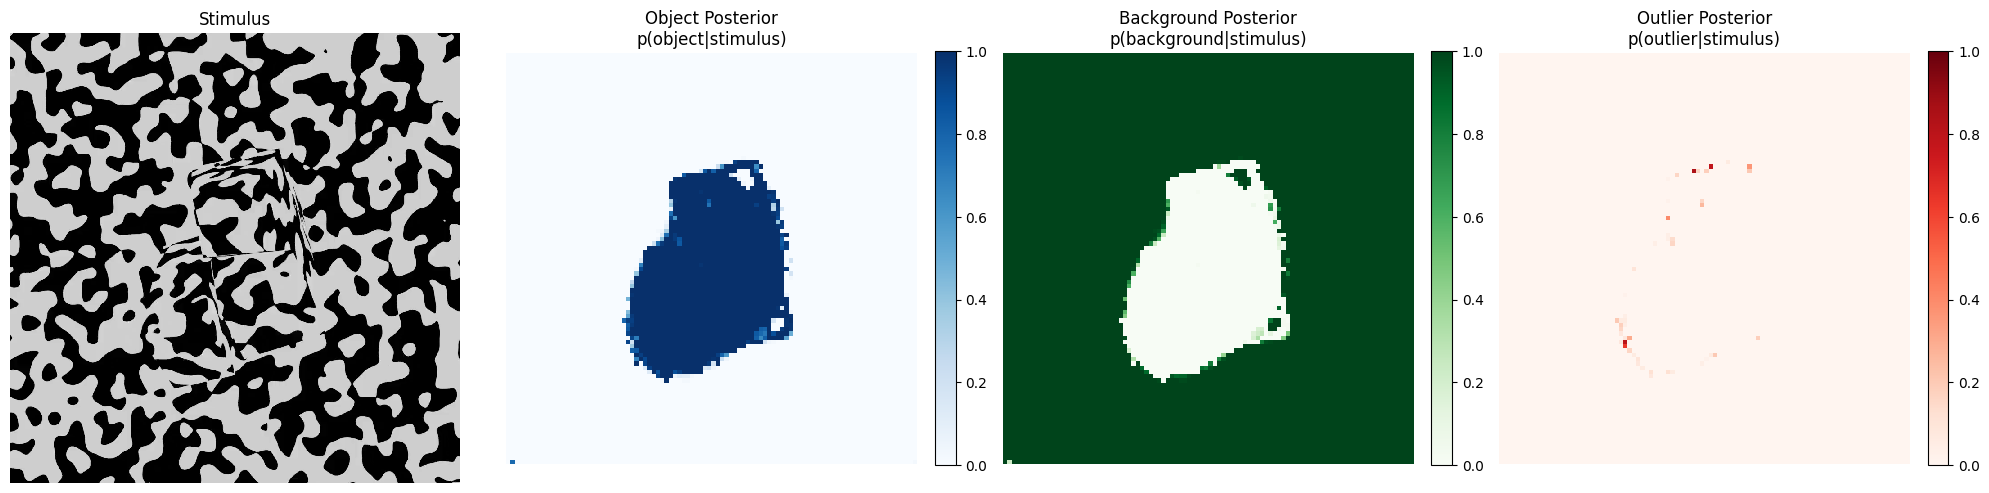

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.animation as animation

# Create animation showing ground truth, binary segmentation, and posteriors
num_frames = binary_segmentation.shape[0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Initialize the plots once to create colorbars
def init():
    # First: Ground truth video frame
    gt_frame = gt_frames[0]
    axes[0].imshow(gt_frame, interpolation='nearest')
    axes[0].set_title('Stimulus')
    axes[0].axis('off')
    
    # Second: Object posterior with colorbar (Blue)
    obj_prob = object_posterior[0]
    im1 = axes[1].imshow(obj_prob, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    axes[1].set_title('Object Posterior\np(object|stimulus)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Third: Background posterior with colorbar (Green)
    bg_prob = background_posterior[0]
    im2 = axes[2].imshow(bg_prob, cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
    axes[2].set_title('Background Posterior\np(background|stimulus)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Fourth: Outlier posterior with colorbar (Red)
    out_prob = outlier_posterior[0]
    im3 = axes[3].imshow(out_prob, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[3].set_title('Outlier Posterior\np(outlier|stimulus)')
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    return axes

def update(frame_idx):
    # Clear only the images, not the colorbars
    for ax in axes:
        for im in ax.images:
            im.remove()
    
    # First: Ground truth video frame
    if frame_idx < len(gt_frames):
        gt_frame = gt_frames[frame_idx]
        axes[0].imshow(gt_frame, interpolation='nearest')
    
    # Second: Object posterior (Blue)
    obj_prob = object_posterior[frame_idx]
    axes[1].imshow(obj_prob, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    
    # Third: Background posterior (Green)
    bg_prob = background_posterior[frame_idx]
    axes[2].imshow(bg_prob, cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
    
    # Fourth: Outlier posterior (Red)
    out_prob = outlier_posterior[frame_idx]
    axes[3].imshow(out_prob, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    
    return axes

# Initialize with colorbars
init()

# Create animation
anim = FuncAnimation(fig, update, frames=num_frames, interval=500, repeat=True)

# Save as video with scene and texture in filename
output_path = f"/home/esli/GenMatter/segmentation_posteriors_{scene_id}_{texture_id}.mp4"
Writer = animation.writers['ffmpeg']
writer = Writer(fps=2, bitrate=1800)
anim.save(output_path, writer=writer)

print(f"Video saved to: {output_path}")

# Display as HTML5 video
HTML(anim.to_jshtml())